In [1]:
%matplotlib inline
from pathlib import Path
import json
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd

In [ ]:
RESULT_JSON = Path("reverse_conv_benchmark_results_0813_effi.json")  # efficient repeates 500
OUTPUT_FIG = Path("reverse_conv_benchmark_results_0813_effi.pdf")

# 字体与颜色。需要中文字体时，可以把 FONT_FAMILY 改成机器上存在的中文字体。
FONT_FAMILY = "DejaVu Sans"
GRID_COLOR = "#bbbbbb"
SPINE_COLOR = "#444444"

# 字号
SUBTITLE_SIZE = 20
AXIS_LABEL_SIZE = 18
TICK_LABEL_SIZE = 18
LEGEND_SIZE = 20

# 线条和点
LINE_WIDTH = 2.5
MARKER_SIZE = 6.5
ALPHA = 0.95

# 刻度样式
TICK_DIRECTION = "in"
TICK_LENGTH = 5
TICK_WIDTH = 1.1

# 方法颜色：同一个 method 在所有子图里始终保持同一种颜色。
METHOD_ORDER = ["exact_matrix", "cg", "fft_oldbound", "fft_pad"]
METHOD_COLORS = {
    "exact_matrix": "tab:blue",
    "cg": "tab:orange",
    "fft_oldbound": "tab:green",
    "fft_pad": "tab:red",
}

# noise_scale 分组样式：同一个 noise_scale 在所有子图里始终保持同一种 marker + linestyle。
# 如果 JSON 里出现这里没有列出的 noise_scale，代码会自动补默认样式。
NOISE_STYLES = {
    1.0: {"marker": "o", "linestyle": "-"},
    5.0: {"marker": "s", "linestyle": "--"},
    10.0: {"marker": "^", "linestyle": ":"},
}


# 横坐标顺序。若 JSON 中 size 不完全一致，后面会自动取交集/补缺失值。
SIZE_ORDER = [16, 32, 64, 128, 256]
PADDING_ORDER = [0, 1]
CASE_ORDER = ["shrink", "expand"]

# 四行指标。第三个元素表示是否允许自动 logscale。
# 用户要求：运行时间和显存需求如果跨度较大，可以使用 logscale；这里仅这两项打开自动 log。
METRICS = [
    ("time_per_call_s", "Time per call (s)", True),
    ("cuda_algorithm_peak_mem_mb", "Algorithm extra peak memory (MB)", True),
    # ("consistency_l2", "Forward consistency L2", False),
    # ("consistency_rel_l2", "Compute consistency relative L2", False),
    # ("front_distance_l2", "Distance to original x L2", False),
    # ("front_distance_rel_l2", "Distance to original x relative L2", False),
]

# 当 allow_log=True 且最大/最小值超过该倍率时，对应子图使用 logscale。
LOG_SPAN_THRESHOLD = 50.0

plt.rcParams.update({
    'font.family': 'serif',
    'mathtext.fontset': 'stix',
})


In [3]:
with RESULT_JSON.open("r", encoding="utf-8") as f:
    exact_records_all = json.load(f)

records = [r for r in exact_records_all]
df = pd.DataFrame(records)
print(f"Merged records: {len(df)}")
print("Columns:", sorted(df.columns.tolist()))

# 只画成功完成的实验。失败记录可以单独检查 df[df['status'] != 'ok']。
if "status" in df.columns:
    failed = df[df["status"] != "ok"].copy()
    ok = df[df["status"] == "ok"].copy()
else:
    failed = pd.DataFrame()
    ok = df.copy()

print(f"OK records: {len(ok)}")
print(f"Failed/skipped records: {len(failed)}")

required_columns = {"method", "case_type", "padding", "noise_scale", "size"}
# missing_columns = sorted(required_columns - set(ok.columns))
# if missing_columns:
#     raise ValueError(f"Missing required columns after merging result files: {missing_columns}")

# 只保留画图需要的 metric 存在的记录；缺失 metric 会在后面子图里自动跳过。
metric_names = [m[0] for m in METRICS] + ["time_per_call_s", "cuda_algorithm_peak_mem_mb"]
for metric in metric_names:
    if metric not in ok.columns:
        print(f"Warning: metric column missing and will be skipped: {metric}")

# 数值字段转为 numeric，避免 JSON 里混入字符串导致 groupby mean 异常。
numeric_columns = ["size",] + [m for m in metric_names if m in ok.columns]
for col in numeric_columns:
    ok[col] = pd.to_numeric(ok[col], errors="coerce")

# ok = ok[ok['seed']==0]

# 同一配置可能有多个 seed / 重复记录，这里取均值。
group_cols = ["case_type", "padding",  "method", "size"]
plot_df = (
    ok.groupby(group_cols, dropna=False)[[m for m in metric_names if m in ok.columns]]
       .mean()
      .reset_index()
)
available_sizes = sorted(int(v) for v in plot_df["size"].dropna().unique())
available_methods = [m for m in METHOD_ORDER if m in set(plot_df["method"])]

print("Available sizes:", available_sizes)
print("Available methods:", available_methods)

# 若数据中的 size 和预设不一致，以预设顺序优先，并追加数据里额外出现的 size。
size_order = available_sizes
noise_order = [1.0, 10.0]
method_order = available_methods
method_name = {'exact_matrix': 'Matrix-Solve', 'cg': 'Iterative-CG', 
               'fft_oldbound': 'FFT-Boundary', 'fft_pad': 'FFT-Padded'}


Merged records: 40
Columns: ['batch_size', 'c_in', 'c_out', 'case_type', 'consistency_l2', 'consistency_max_abs', 'consistency_rel_l2', 'conv_matrix_condition', 'cuda_algorithm_peak_mem_mb', 'cuda_algorithm_peak_reserved_mb', 'cuda_baseline_allocated_mb', 'cuda_baseline_reserved_mb', 'cuda_end_allocated_mb', 'cuda_end_reserved_mb', 'cuda_peak_mem_mb', 'cuda_peak_reserved_mb', 'device', 'effective_rank', 'effective_rank_ratio', 'error', 'front_distance_l2', 'front_distance_rel_l2', 'kernel_size', 'max_kernel_rank', 'method', 'padding', 'rank_mode', 'repeats', 'requested_condition', 'seed', 'size', 'status', 'time_per_call_s', 'time_total_s', 'use_regu', 'weight_condition', 'weight_scale', 'x_shape', 'y_shape']
OK records: 38
Failed/skipped records: 2
Available sizes: [16, 32, 64, 128, 256]
Available methods: ['exact_matrix', 'cg', 'fft_oldbound', 'fft_pad']


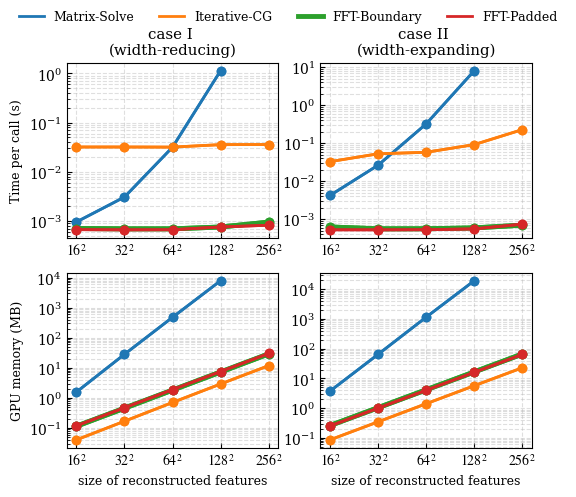

In [4]:
plt.rcParams.update({
    'font.family': 'serif',
    'mathtext.fontset': 'stix'
})
plt.rcParams['font.size'] = 9
fig, axs = plt.subplots(2, 2, figsize=(6, 5))
for method in method_order:
    if method != 'fft_oldbound':
        lw = 2
    else: lw = 3.5
    time_shrink = plot_df[(plot_df['method'] == method) & (plot_df['case_type'] == 'shrink') \
                          & (plot_df['padding']==0)].sort_values(by='size')['time_per_call_s'].values
    time_expand = plot_df[(plot_df['method'] == method) & (plot_df['case_type'] == 'expand')\
                          & (plot_df['padding']==0)].sort_values(by='size')['time_per_call_s'].values
    memory_shrink = plot_df[(plot_df['method'] == method) & (plot_df['case_type'] == 'shrink')\
                            & (plot_df['padding']==0)].sort_values(by='size')['cuda_algorithm_peak_mem_mb'].values
    memory_expand = plot_df[(plot_df['method'] == method) & (plot_df['case_type'] == 'expand')\
                            & (plot_df['padding']==0)].sort_values(by='size')['cuda_algorithm_peak_mem_mb'].values
    if method == 'exact_matrix':
        x_loc = [1,2,3,4]
    else: x_loc = [1,2,3,4,5]
    axs[0,0].plot(x_loc, time_shrink, color=METHOD_COLORS.get(method, None), linestyle='-',marker='o', linewidth=lw)
    axs[0,1].plot(x_loc, time_expand, color=METHOD_COLORS.get(method, None), linestyle='-',marker='o', linewidth=lw)
    axs[1,0].plot(x_loc, memory_shrink, color=METHOD_COLORS.get(method, None), linestyle='-',marker='o', linewidth=lw)
    axs[1,1].plot(x_loc, memory_expand, color=METHOD_COLORS.get(method, None), linestyle='-',marker='o', linewidth=lw)

axs[0,0].set_title('case I \n(width-reducing)')
axs[0, 0].set_ylabel('Time per call (s)')
axs[0,1].set_title('case II \n(width-expanding)')
axs[1,0].set_ylabel('GPU memory (MB)')
axs[1,0].set_xlabel('size of reconstructed features')
axs[1,1].set_xlabel('size of reconstructed features')

for ax in axs.ravel():
    ax.set_yscale('log')
    ax.set_xticks([1,2,3,4,5])
    ax.set_xticklabels([r'$16^{2}$',r'$32^{2}$',r'$64^{2}$',r'$128^{2}$', r'$256^{2}$'])
    # ax.legend(fontsize=8)

    ax.tick_params(
        axis='both',
        direction='in',
        labelsize=10
    )
    ax.tick_params(axis='y', which='major', direction='in')
    ax.tick_params(axis='y', which='minor', direction='in')

    ax.grid(True, which='both', linestyle='--', alpha=0.4)

method_handles = [
    Line2D(
        [0],
        [0],
        color=METHOD_COLORS.get(method, "black"),
        label=method_name[method],
        linewidth=2 if method != 'fft_oldbound' else 3.5,
    )
    for method in method_order
]
fig.legend(
    handles=method_handles,
    loc="upper center",
    ncol=max(1, len(method_handles)),
    frameon=False,
)
plt.savefig("conv_reverse_effi.png",dpi=600)
plt.show()

## discard

NameError: name 'plot_df' is not defined

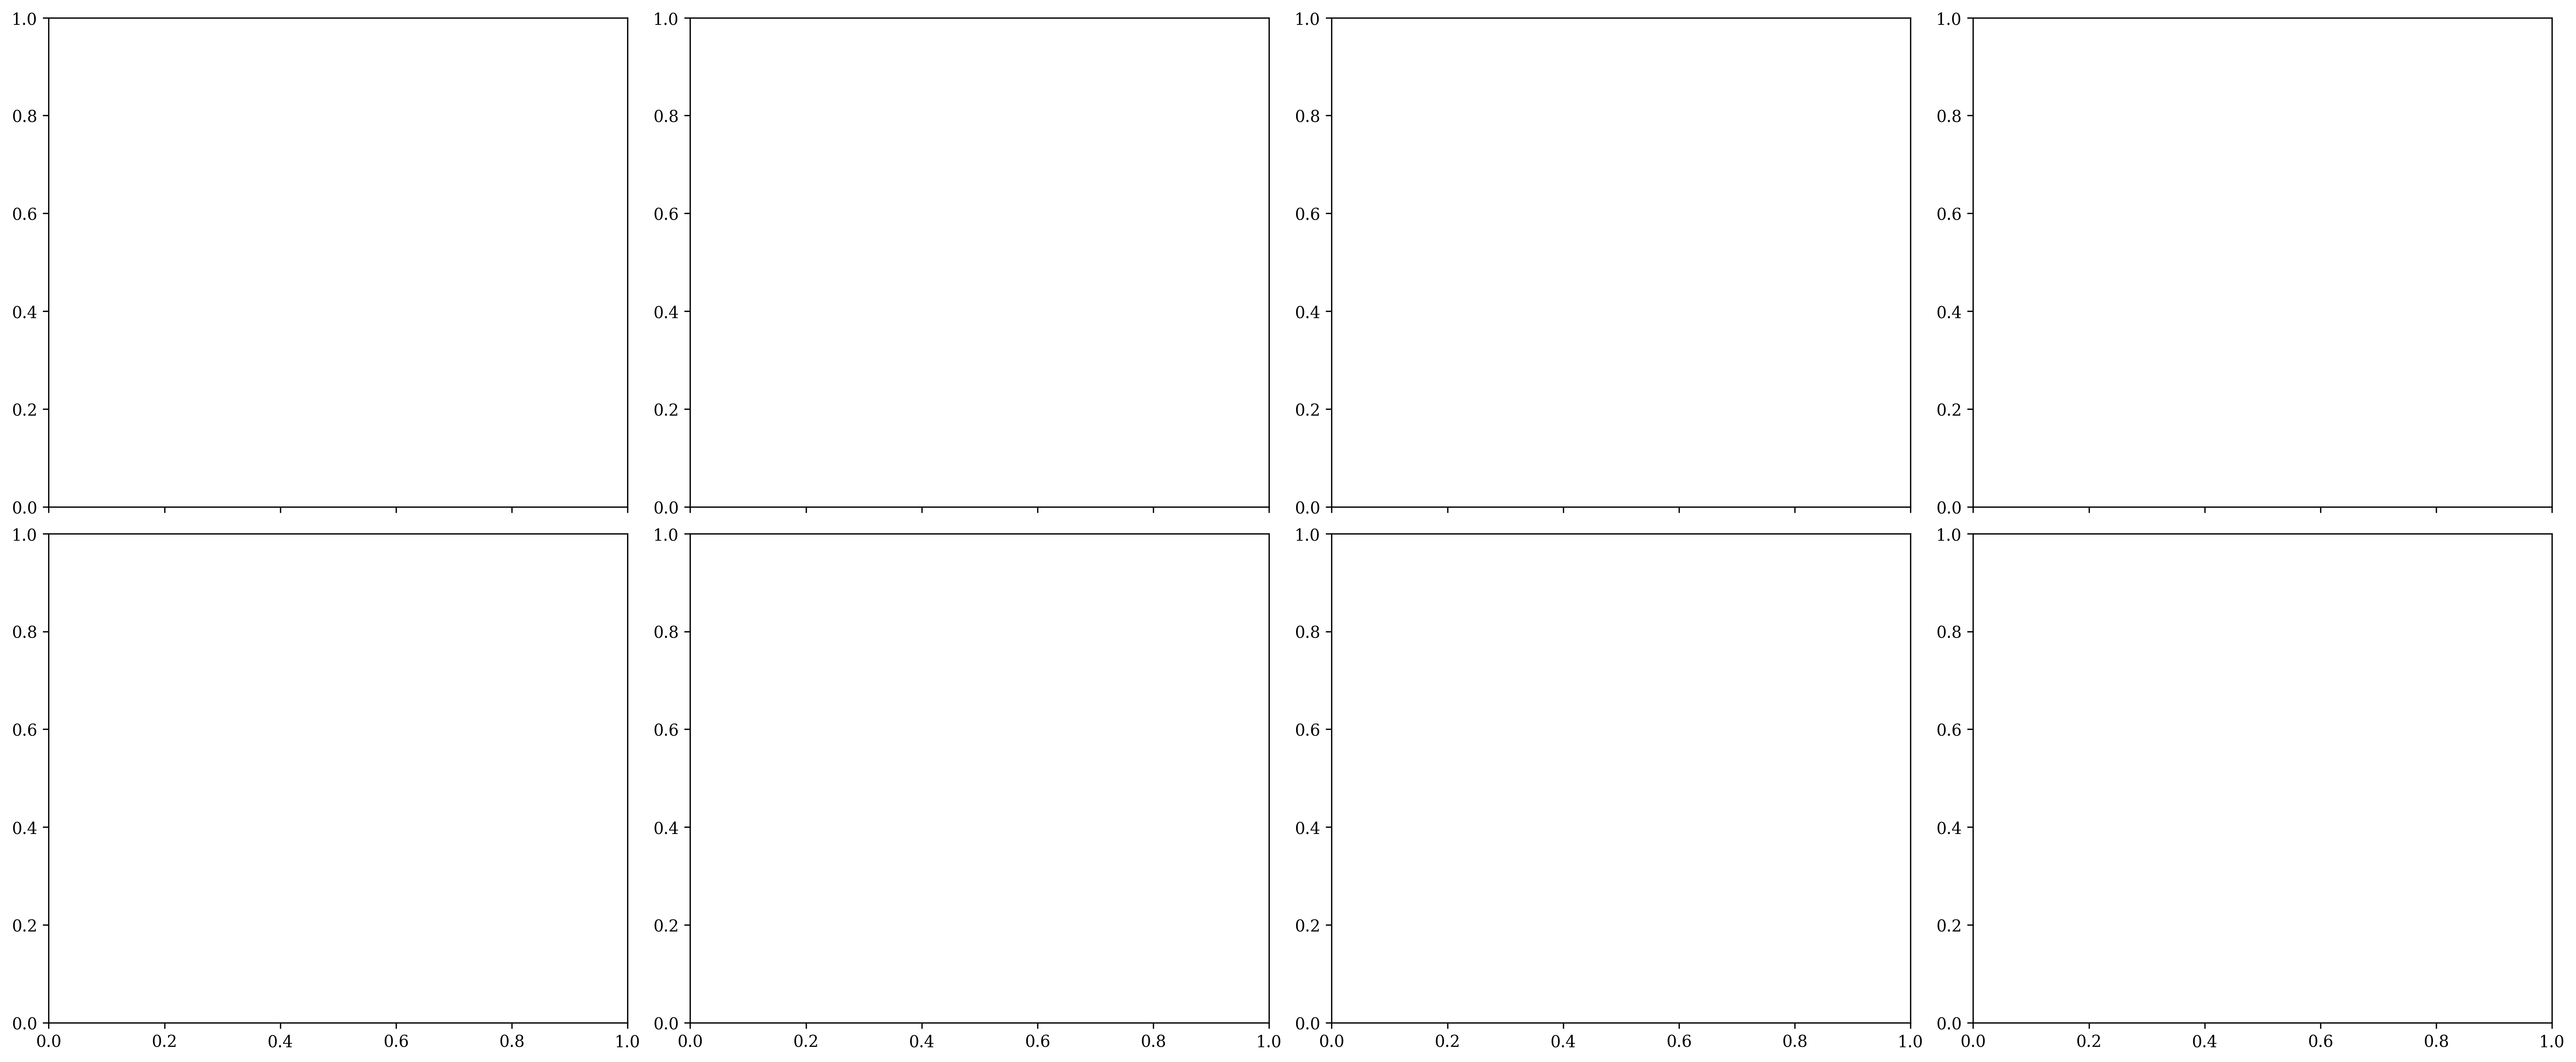

In [3]:
def style_for_noise(noise_value):
    """Return marker/linestyle for a noise_scale value."""
    noise_value = float(noise_value)
    if noise_value in NOISE_STYLES:
        return NOISE_STYLES[noise_value]
    return None
    idx = int(abs(hash(noise_value))) % len(DEFAULT_NOISE_STYLES)
    return DEFAULT_NOISE_STYLES[idx]


def should_use_logscale(values, allow_log):
    """Use logscale only for positive values spanning a large dynamic range."""
    return True
    if not allow_log:
        return False
    values = pd.Series(values).dropna()
    values = values[values > 0]
    if values.empty:
        return False
    return (values.max() / values.min()) >= LOG_SPAN_THRESHOLD

# 图像尺寸和分辨率
FIGSIZE = (22, 9) # w, h; slightly flatter subplots
DPI = 300

fig, axes = plt.subplots(
    nrows=2,
    ncols=4,
    figsize=FIGSIZE,
    dpi=DPI,
    sharex=True,
    constrained_layout=True,
)


column_specs = [("shrink", p) for p in PADDING_ORDER] + [("expand", p) for p in PADDING_ORDER]

for row_idx, (metric, ylabel, allow_log) in enumerate(METRICS):
    for col_idx, (case_type, padding) in enumerate(column_specs):
        ax = axes[row_idx, col_idx]
        sub = plot_df[(plot_df["case_type"] == case_type) & (plot_df["padding"] == padding)]

        if metric not in plot_df.columns or sub.empty:
            raise
            ax.text(
                0.5,
                0.5,
                "No data",
                ha="center",
                va="center",
                fontsize=AXIS_LABEL_SIZE,
                transform=ax.transAxes,
            )
        else:
            for noise_scale in noise_order:
                noise_sub = sub[sub["noise_scale"] == noise_scale]
                noise_style = style_for_noise(noise_scale)

                for method in method_order:
                    method_sub = noise_sub[noise_sub["method"] == method]
                    if method_sub.empty:
                        continue

                    series = (
                        method_sub.groupby("size")[metric]
                        .mean()
                        .reindex(size_order)
                    )
                    if series.dropna().empty:
                        continue
                    if row_idx == 0 and col_idx == 0:
                        series *= 1e4

                    x_positions = np.arange(len(size_order))
                    ax.plot(
                        x_positions,
                        series.values,
                        color=METHOD_COLORS.get(method, None),
                        linestyle=noise_style["linestyle"],
                        marker=noise_style["marker"],
                        linewidth=(LINE_WIDTH if method != 'exact_matrix' else LINE_WIDTH + 3),
                        markersize=MARKER_SIZE,
                        alpha=ALPHA,
                    )

            if should_use_logscale(sub[metric], allow_log):
                ax.set_yscale("log")

        # 第一行写列标题：case + padding。
        if row_idx == 0:
            casenum = 1 if case_type == "shrink" else 2
            ax.set_title(
                f"case {casenum} (padding={padding})",
                fontsize=SUBTITLE_SIZE,
                pad=8,
            )

        # 第一列写行指标名。每一列也保留 y tick，方便横向比较。
        if col_idx == 0:
            ax.set_ylabel(ylabel, fontsize=AXIS_LABEL_SIZE)

        # 最后一行写横轴标签。
        if row_idx == len(METRICS) - 1:
            ax.set_xlabel("size of lhs feature maps", fontsize=AXIS_LABEL_SIZE)

        ax.set_xticks(np.arange(len(size_order)))
        # ax.set_xticklabels([str(s) for s in size_order])
        ax.set_xticklabels([rf"${s}^2$" for s in size_order])
        ax.tick_params(
            axis="both",
            which="both",
            direction=TICK_DIRECTION,
            labelsize=TICK_LABEL_SIZE,
            length=TICK_LENGTH,
            width=TICK_WIDTH,
            top=False,
            right=False,
        )
        if row_idx == 0 and col_idx == 0:
            for label in ax.get_yticklabels():
                text = label.get_text()
                if text and "1e-4" in text:
                    label.set_fontweight("bold")
                    label.set_color("black")
            ax.annotate(
                r"$\times$ 1e-4",
                xy=(0.05, 0.91),
                xycoords="axes fraction",
                xytext=(0, 0),
                textcoords="offset points",
                ha="left",
                va="center",
                fontsize=TICK_LABEL_SIZE + 2,
                color="black",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.85),
            )
        if row_idx == 1:# and col_idx == 2:
            ax.set_yscale('log')
        ax.grid(True, which="both", color=GRID_COLOR, alpha=0.5, linewidth=0.8)
        for spine in ax.spines.values():
            spine.set_color(SPINE_COLOR)

# 两个图例分开：颜色代表 method，线型/marker 代表 noise_scale。

method_handles = [
    Line2D(
        [0],
        [0],
        color=METHOD_COLORS.get(method, "black"),
        linewidth=LINE_WIDTH + 0.5,
        label=method_name.get(method, method)
    )
    for method in method_order
]

noise_handles = []
for noise_scale in noise_order:
    noise_style = style_for_noise(noise_scale)
    noise_handles.append(
        Line2D(
            [0],
            [0],
            color="black",
            linewidth=LINE_WIDTH,
            linestyle=noise_style["linestyle"],
            marker=noise_style["marker"],
            markersize=MARKER_SIZE,
            label=f"rhs_perturb_scale={noise_scale:g}",
        )
    )

# Two separate figure-level legends keep the semantics clear:
# first row = algorithm methods, second row = RHS perturbation scales.
# The y anchors are placed above the axes area to avoid overlapping subplot titles.
fig.legend(
    handles=method_handles,
    loc="upper center",
    bbox_to_anchor=(0.3, 1.065),
    ncol=max(1, len(method_handles)),
    fontsize=LEGEND_SIZE,
    frameon=False,
    columnspacing=1.8,
    handlelength=2.5,
)
fig.legend(
    handles=noise_handles,
    loc="upper center",
    bbox_to_anchor=(0.8, 1.065),
    ncol=max(1, len(noise_handles)),
    fontsize=LEGEND_SIZE,
    frameon=False,
    columnspacing=1.8,
    handlelength=2.5,
)

# Leave extra space for the two legend rows above the subplot titles.
fig.set_constrained_layout_pads(h_pad=0.08, w_pad=0.04, hspace=0.08, wspace=0.04)

fig.savefig(OUTPUT_FIG, dpi=DPI, bbox_inches="tight")
print(f"Saved figure to: {OUTPUT_FIG.resolve()}")
plt.show()

## condition 

In [5]:
RESULT_JSON_FALSE = Path("reverse_conv_benchmark_results_0813as1_acc.json")
RESULT_JSON = Path("reverse_conv_benchmark_results_0813fft1e3ampt0l1e2_acc.json")
OUTPUT_FIG = Path("reverse_conv_benchmark_results_0813fft1e3ampt0l1e2_acc.pdf")


# 字体与颜色。需要中文字体时，可以把 FONT_FAMILY 改成机器上
# 存在的中文字体。
FONT_FAMILY = "DejaVu Sans"
GRID_COLOR = "#bbbbbb"
SPINE_COLOR = "#444444"

# 字号
SUBTITLE_SIZE = 20
AXIS_LABEL_SIZE = 18
TICK_LABEL_SIZE = 18
LEGEND_SIZE = 20

# 线条和点
LINE_WIDTH = 2.5
MARKER_SIZE = 6.5
ALPHA = 0.95

# 刻度样式
TICK_DIRECTION = "in"
TICK_LENGTH = 5
TICK_WIDTH = 1.1

# 方法颜色：同一个 method 在所有子图里始终保持同一种颜色。
METHOD_ORDER = ["exact_matrix", "cg", "fft_oldbound", "fft_pad"]
METHOD_COLORS = {
    "exact_matrix": "tab:blue",
    "cg": "tab:orange",
    "fft_oldbound": "tab:green",
    "fft_pad": "tab:red",
}


REGU_STYLES = {
    True: {"marker": "o", "linestyle": "-", "alpha":1.0, "markersize":10},
    False: {"marker": "*", "linestyle": "--", "alpha":0.7, "markersize":13},
}

# 横坐标顺序。若 JSON 中 size 不完全一致，后面会自动取交集/补缺失值。
PADDING_ORDER = [0, 1]
CASE_ORDER = ["shrink", "expand"]

# 四行指标。第三个元素表示是否允许自动 logscale。
# 用户要求：运行时间和显存需求如果跨度较大，可以使用 logscale；这里仅这两项打开自动 log。
METRICS = [
    # ("time_per_call_s", "Time per call (s)", True),
    # ("cuda_algorithm_peak_mem_mb", "Algorithm extra peak memory (MB)", True),
    # ("consistency_l2", "Forward consistency L2", False),
    ("consistency_rel_l2", "Compute consistency relative L2", False),
    # ("front_distance_l2", "Distance to original x L2", False),
    ("front_distance_rel_l2", "Distance to original x relative L2", False),
]

# 当 allow_log=True 且最大/最小值超过该倍率时，对应子图使用 logscale。
LOG_SPAN_THRESHOLD = 50.0

plt.rcParams.update({
    'font.family': 'serif',
    'mathtext.fontset': 'stix',
})


In [6]:
with RESULT_JSON_FALSE.open("r", encoding="utf-8") as f:
    exact_records_false = json.load(f)

with RESULT_JSON.open("r", encoding="utf-8") as f:
    exact_records_all = json.load(f)

records = [r for r in exact_records_all]+ [r for r in exact_records_false if not r["use_regu"]]
df = pd.DataFrame(records)
print(f"Merged records: {len(df)}")
print("Columns:", sorted(df.columns.tolist()))

# 只画成功完成的实验。失败记录可以单独检查 df[df['status'] != 'ok']。
if "status" in df.columns:
    failed = df[df["status"] != "ok"].copy()
    ok = df[df["status"] == "ok"].copy()
else:
    failed = pd.DataFrame()
    ok = df.copy()

print(f"OK records: {len(ok)}")
print(f"Failed/skipped records: {len(failed)}")

required_columns = {"method", "case_type", "padding", "requested_condition", "use_regu"}
# missing_columns = sorted(required_columns - set(ok.columns))
# if missing_columns:
#     raise ValueError(f"Missing required columns after merging result files: {missing_columns}")

# 只保留画图需要的 metric 存在的记录；缺失 metric 会在后面子图里自动跳过。
metric_names = [m[0] for m in METRICS]
for metric in metric_names:
    if metric not in ok.columns:
        print(f"Warning: metric column missing and will be skipped: {metric}")

# 数值字段转为 numeric，避免 JSON 里混入字符串导致 groupby mean 异常。
numeric_columns = ["padding", "requested_condition"] + [m for m in metric_names if m in ok.columns]
for col in numeric_columns:
    ok[col] = pd.to_numeric(ok[col], errors="coerce")

# ok = ok[ok['seed']==0]

# 同一配置可能有多个 seed / 重复记录，这里取均值。
group_cols = ["c_out", "padding", "method", "requested_condition", "use_regu"]
plot_df = (
    ok.groupby(group_cols, dropna=False)[[m for m in metric_names if m in ok.columns]]
       .mean()
      .reset_index()
)
plot_df['use_regu']= plot_df['use_regu'].astype(int)
available_cout = sorted(v for v in plot_df['c_out'].unique())
available_cond = sorted(int(v) for v in plot_df["requested_condition"].unique())
available_regu = [v for v in plot_df["use_regu"].unique()]
available_methods = [m for m in METHOD_ORDER if m in set(plot_df["method"])]

print("Available cout:", available_cout)
print("Available sizes:", available_cond)
print("Available regu:", available_regu)
print("Available methods:", available_methods)

# 若数据中的 size 和预设不一致，以预设顺序优先，并追加数据里额外出现的 size。
cond_order = available_cond
method_order = available_methods
method_name = {'exact_matrix': 'Matrix-Solve', 'cg': 'Iterative-CG', 
               'fft_oldbound': 'FFT-Boundary', 'fft_pad': 'FFT-Padded'}


Merged records: 2880
Columns: ['batch_size', 'c_in', 'c_out', 'case_type', 'consistency_l2', 'consistency_max_abs', 'consistency_rel_l2', 'conv_matrix_condition', 'device', 'effective_rank', 'effective_rank_ratio', 'front_distance_l2', 'front_distance_rel_l2', 'kernel_size', 'max_kernel_rank', 'method', 'padding', 'physical_gpu', 'rank_mode', 'repeats', 'requested_condition', 'seed', 'size', 'status', 'use_regu', 'weight_condition', 'weight_scale', 'x_shape', 'y_shape']
OK records: 2880
Failed/skipped records: 0
Available cout: [np.int64(4), np.int64(8), np.int64(16)]
Available sizes: [1, 10, 100, 1000, 10000, 100000]
Available regu: [np.int64(0), np.int64(1)]
Available methods: ['exact_matrix', 'cg', 'fft_oldbound', 'fft_pad']


Saved figure to: /data/dn/FRTP_revision1/effi_stab_exp/reverse_conv_benchmark_results_0813fft1e3ampt0l1e2_acc.pdf


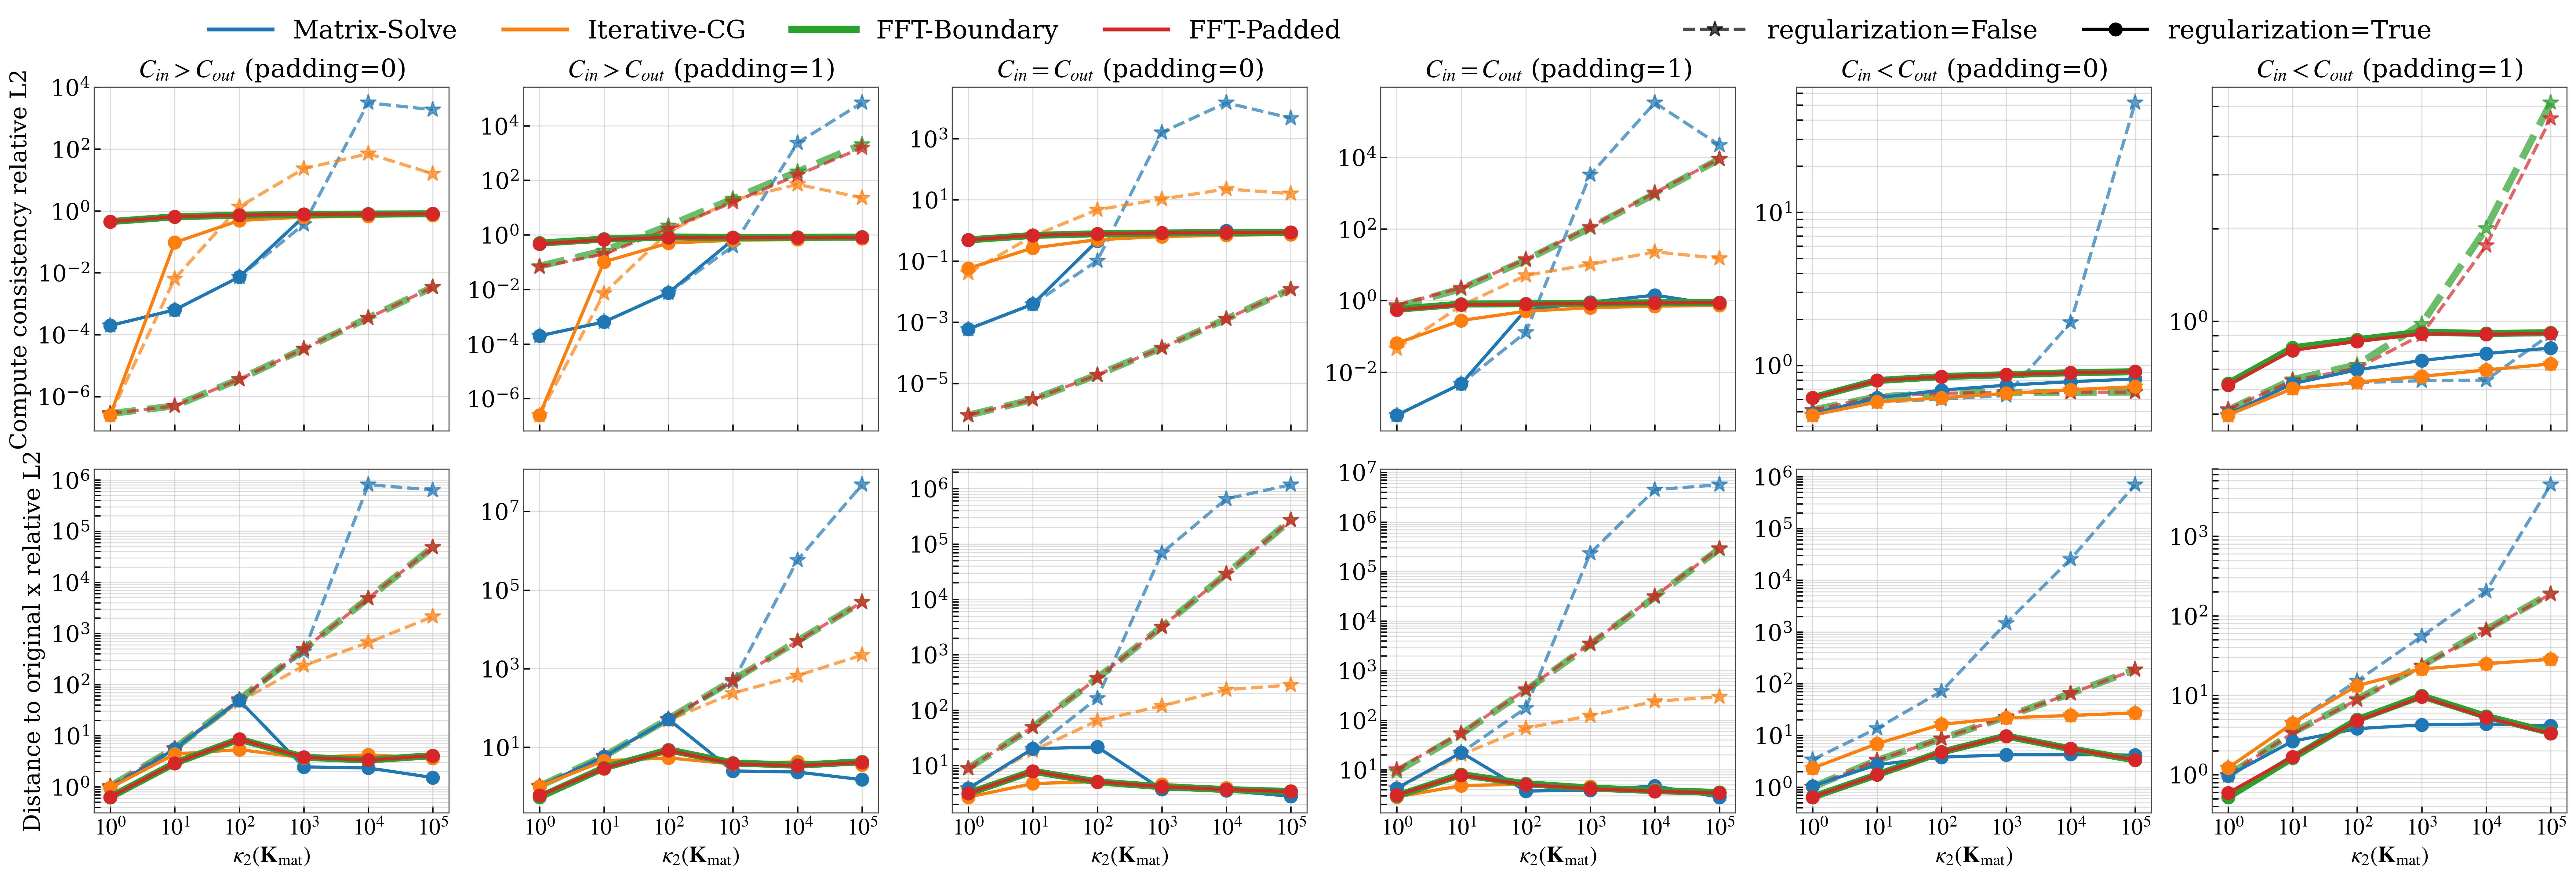

: 

In [ ]:
def style_for_regu(regu_value):
    if regu_value in REGU_STYLES:
        return REGU_STYLES[regu_value]
    return None
    idx = int(abs(hash(noise_value))) % len(DEFAULT_NOISE_STYLES)
    return DEFAULT_NOISE_STYLES[idx]


def should_use_logscale(values, allow_log):
    """Use logscale only for positive values spanning a large dynamic range."""
    return True
    if not allow_log:
        return False
    values = pd.Series(values).dropna()
    values = values[values > 0]
    if values.empty:
        return False
    return (values.max() / values.min()) >= LOG_SPAN_THRESHOLD

# 图像尺寸和分辨率
FIGSIZE = (28, 9) # w, h; slightly flatter subplots
DPI = 300

fig, axes = plt.subplots(
    nrows=2,
    ncols=6,
    figsize=FIGSIZE,
    dpi=DPI,
    sharex=True,
    constrained_layout=True,
)


column_specs = [(c, p) for c in available_cout for p in PADDING_ORDER]

for row_idx, (metric, ylabel, allow_log) in enumerate(METRICS):
    for col_idx, (cout, padding) in enumerate(column_specs):
        ax = axes[row_idx, col_idx]
        sub = plot_df[(plot_df["c_out"] == cout) & (plot_df["padding"] == padding)]

        if metric not in plot_df.columns or sub.empty:
            raise
            ax.text(
                0.5,
                0.5,
                "No data",
                ha="center",
                va="center",
                fontsize=AXIS_LABEL_SIZE,
                transform=ax.transAxes,
            )
        else:
            for regu in available_regu:
                regu_sub = sub[sub["use_regu"] == regu]
                regu_style = style_for_regu(regu)

                for method in method_order:
                    method_sub = regu_sub[regu_sub["method"] == method]
                    if method_sub.empty:
                        continue

                    series = (
                        method_sub.groupby("requested_condition")[metric]
                        .mean()
                        .reindex(available_cond)
                    )
                    if series.dropna().empty:
                        continue

                    x_positions = np.arange(len(available_cond))
                    ax.plot(
                        x_positions,
                        series.values,
                        color=METHOD_COLORS.get(method, None),
                        linestyle=regu_style["linestyle"],
                        marker=regu_style["marker"],
                        # linewidth=LINE_WIDTH,
                        linewidth=(LINE_WIDTH if method not in ['fft_oldbound']  else LINE_WIDTH + 3),
                        markersize=regu_style["markersize"],
                        alpha=regu_style["alpha"],
                    )

            if should_use_logscale(sub[metric], allow_log):
                ax.set_yscale("log")

        # 第一行写列标题：case + padding。
        if row_idx == 0:
            if cout == 4:
                ax.set_title(r"$C_{in}>C_{out}$"+ f" (padding={padding})",fontsize=SUBTITLE_SIZE,pad=8)
            elif cout == 8:
                ax.set_title(r"$C_{in}=C_{out}$"+ f" (padding={padding})",fontsize=SUBTITLE_SIZE,pad=8)
            elif cout == 16:
                ax.set_title(r"$C_{in}<C_{out}$"+ f" (padding={padding})",fontsize=SUBTITLE_SIZE,pad=8)

        # 第一列写行指标名。每一列也保留 y tick，方便横向比较。
        if col_idx == 0:
            ax.set_ylabel(ylabel, fontsize=AXIS_LABEL_SIZE)

        # 最后一行写横轴标签。
        if row_idx == len(METRICS) - 1:
            ax.set_xlabel(r"$\kappa_{2}(\mathbf{K}_{\mathrm{mat}})$", fontsize=AXIS_LABEL_SIZE)

        ax.set_xticks(np.arange(len(available_cond)))
        ax.set_xticklabels([rf"$10^{i}$" for i in range(len(available_cond))])
        ax.tick_params(
            axis="both",
            which="both",
            direction=TICK_DIRECTION,
            labelsize=TICK_LABEL_SIZE,
            length=TICK_LENGTH,
            width=TICK_WIDTH,
            top=False,
            right=False,
        )

        if row_idx != 0 or col_idx != 4:# and col_idx == 2:
            ax.set_yscale('log')
        ax.grid(True, which="both", color=GRID_COLOR, alpha=0.5, linewidth=0.8)
        for spine in ax.spines.values():
            spine.set_color(SPINE_COLOR)


method_handles = [
    Line2D(
        [0],
        [0],
        color=METHOD_COLORS.get(method, "black"),
        linewidth=(LINE_WIDTH+0.5 if method not in ['fft_oldbound'] else LINE_WIDTH + 3.5),
        # linewidth=LINE_WIDTH + 0.5,
        label=method_name.get(method, method)
    )
    for method in method_order
]

regu_handles = []
for regu in available_regu:
    regu_style = style_for_regu(regu)
    regu_handles.append(
        Line2D(
            [0],
            [0],
            color="black",
            linewidth=LINE_WIDTH,
            linestyle=regu_style["linestyle"],
            marker=regu_style["marker"],
            alpha=regu_style["alpha"],
            markersize=regu_style["markersize"],
            label=f"regularization={bool(regu)}",
        )
    )

# Two separate figure-level legends keep the semantics clear:
# first row = algorithm methods, second row = RHS perturbation scales.
# The y anchors are placed above the axes area to avoid overlapping subplot titles.
fig.legend(
    handles=method_handles,
    loc="upper center",
    bbox_to_anchor=(0.3, 1.065),
    ncol=max(1, len(method_handles)),
    fontsize=LEGEND_SIZE,
    frameon=False,
    columnspacing=1.8,
    handlelength=2.5,
)
fig.legend(
    handles=regu_handles,
    loc="upper center",
    bbox_to_anchor=(0.8, 1.065),
    ncol=max(1, len(regu_handles)),
    fontsize=LEGEND_SIZE,
    frameon=False,
    columnspacing=1.8,
    handlelength=2.5,
)

# Leave extra space for the two legend rows above the subplot titles.
fig.set_constrained_layout_pads(h_pad=0.08, w_pad=0.04, hspace=0.08, wspace=0.04)

fig.savefig(OUTPUT_FIG, dpi=DPI, bbox_inches="tight")
print(f"Saved figure to: {OUTPUT_FIG.resolve()}")
plt.show()